In [1]:
library(Signac)
library(Seurat)
library(ggplot2)
library(GenomicRanges)
library(BiocParallel)
library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)
suppressPackageStartupMessages(library(scDblFinder))
library(future)

plan("multicore", workers = 24)
options(future.globals.maxSize = 100000 * 1024^3)

set.seed(1234)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, saveRDS


Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays: Please run: options(Seurat.object.assay.version = 'v5')

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax

### Doublet detection

#### `scDblFinder`

In [2]:
multiome <- readRDS('data/multiome_common_peak_set_dmg_atlas_qc_filtered.rds')
multiome

$GNG_region_11
An object of class Seurat 
378298 features across 7216 samples within 1 assay 
Active assay: ATAC (378298 features, 0 variable features)
 2 layers present: counts, data

$`P-1694_S-1694`
An object of class Seurat 
378298 features across 5079 samples within 1 assay 
Active assay: ATAC (378298 features, 0 variable features)
 2 layers present: counts, data

$`P-1701_S-1701`
An object of class Seurat 
378298 features across 12982 samples within 1 assay 
Active assay: ATAC (378298 features, 0 variable features)
 2 layers present: counts, data

$`P-1709_S-1709`
An object of class Seurat 
378298 features across 19181 samples within 1 assay 
Active assay: ATAC (378298 features, 0 variable features)
 2 layers present: counts, data

$`P-1764_S-1766`
An object of class Seurat 
378298 features across 8693 samples within 1 assay 
Active assay: ATAC (378298 features, 0 variable features)
 2 layers present: counts, data

$`P-1779_S-1781`
An object of class Seurat 
378298 features acros

In [3]:
multiome_merged <- merge(multiome[[1]], y = unlist(multiome[2:length(multiome)]))
bp <- MulticoreParam(12, RNGseed=1234)
doublets_multiome <- scDblFinder(GetAssayData(multiome_merged, slot="counts"), 
                                samples=multiome_merged$SampleID, 
                                clusters=TRUE, aggregateFeatures=TRUE, nfeatures=25, 
                                processing="normFeatures",
                                BPPARAM=bp)
doublets_multiome

Warning message:
"The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead."
Assuming the input to be a matrix of counts or expected counts.

R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 str

class: SingleCellExperiment 
dim: 378298 99736 
metadata(2): scDblFinder.stats scDblFinder.threshold
assays(1): counts
rownames(378298): chr1-9729-10741 chr1-15764-16590 ...
  KI270721.1-46484-47618 KI270726.1-13856-14767
rowData names(0):
colnames(99736): GNG_region_11_AAACAGCCAAAGCGGC-1
  GNG_region_11_AAACAGCCAGGTTCAC-1 ...
  multiome_P-6774_S-10146_TTTGTTGGTTGTAACG-1
  multiome_P-6774_S-10146_TTTGTTGGTTTATCGC-1
colData names(9): scDblFinder.sample scDblFinder.cluster ...
  scDblFinder.mostLikelyOrigin scDblFinder.originAmbiguous
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [4]:
multiome_merged

An object of class Seurat 
378298 features across 99736 samples within 1 assay 
Active assay: ATAC (378298 features, 0 variable features)
 2 layers present: counts, data

In [5]:
head(doublets_multiome$scDblFinder.score)
head(doublets_multiome$scDblFinder.class)

[1] 0.020549510 0.120021418 0.001335426 0.202490866 0.037750602 0.195009470

[1] singlet singlet singlet singlet singlet singlet
Levels: singlet doublet

In [6]:
multiome_merged$scDblFinder.score <- doublets_multiome$scDblFinder.score
multiome_merged$scDblFinder.class <- doublets_multiome$scDblFinder.class

#### `Amulet`

In [7]:
repeats <- GRanges("chr6", IRanges(1000,2000))
# it's better to combine these with mitochondrial and sex chromosomes
otherChroms <- GRanges(c("M","chrM","MT","X","Y","chrX","chrY"),IRanges(1L,width=10^8))
# here since I don't know what chromosome notation you'll be using I've just put them all,
# although this will trigger a warning when combining them:
toExclude <- suppressWarnings(c(repeats, otherChroms))

# Create an empty list to store the amulet scores per sample
amulet_list <- list()

for (i in seq_along(multiome)) {
    fragfile <- Fragments(multiome[[i]])[[1]]@path
    barcodes <- unname(Fragments(multiome[[i]])[[1]]@cells)
    
    res <- amulet(fragfile, regionsToExclude=toExclude, barcodes = barcodes, fullInMemory=TRUE)
    amulet_list[[i]] <- res
    }

11:05:34 PM - Reading full fragments...

11:14:30 PM - Splitting and subsetting barcodes...

11:15:39 PM - Obtaining overlaps...

11:25:53 PM - Reading full fragments...

11:30:27 PM - Splitting and subsetting barcodes...

11:30:54 PM - Obtaining overlaps...

11:37:26 PM - Reading full fragments...

11:43:03 PM - Splitting and subsetting barcodes...

11:43:47 PM - Obtaining overlaps...

12:00:19 AM - Reading full fragments...

12:05:16 AM - Splitting and subsetting barcodes...

12:05:50 AM - Obtaining overlaps...

12:29:11 AM - Reading full fragments...

12:35:22 AM - Splitting and subsetting barcodes...

12:36:12 AM - Obtaining overlaps...

12:47:19 AM - Reading full fragments...

12:53:23 AM - Splitting and subsetting barcodes...

12:54:14 AM - Obtaining overlaps...

01:07:24 AM - Reading full fragments...

01:12:06 AM - Splitting and subsetting barcodes...

01:12:45 AM - Obtaining overlaps...

01:23:21 AM - Reading full fragments...

01:29:54 AM - Splitting and subsetting barcodes..

In [8]:
head(amulet_list, n = 1)

,nFrags,uniqFrags,nAbove2,total.nAbove2,p.value,q.value
,<int>,<int>,<int>,<int>,<dbl>,<dbl>
AAACAGCCAAAGCGGC-1,12223,12223,0,1,1.000000e+00,1.000000e+00
AAACAGCCAGGTTCAC-1,10699,10699,0,0,1.000000e+00,1.000000e+00
AAACATGCAACTGGCT-1,4803,4803,0,0,1.000000e+00,1.000000e+00
AAACATGCACGAACAG-1,41593,41593,6,8,9.999859e-01,1.000000e+00
AAACATGCAGGCCAAA-1,540888,540888,135,226,4.135571e-56,9.657695e-55
AAACCAACACACAATT-1,30729,30729,2,3,1.000000e+00,1.000000e+00
AAACCAACACGTTACA-1,21770,21770,0,2,1.000000e+00,1.000000e+00
AAACCAACATCATGTG-1,16569,16569,0,1,1.000000e+00,1.000000e+00
AAACCAACATGATTGT-1,7104,7104,0,1,1.000000e+00,1.000000e+00


In [9]:
amulet_multiome <- do.call(rbind, amulet_list)
rownames(amulet_multiome) <- rownames(multiome_merged@meta.data)
amulet_multiome

,nFrags,uniqFrags,nAbove2,total.nAbove2,p.value,q.value
,<int>,<int>,<int>,<int>,<dbl>,<dbl>
GNG_region_11_AAACAGCCAAAGCGGC-1,12223,12223,0,1,1.000000e+00,1.000000e+00
GNG_region_11_AAACAGCCAGGTTCAC-1,10699,10699,0,0,1.000000e+00,1.000000e+00
GNG_region_11_AAACATGCAACTGGCT-1,4803,4803,0,0,1.000000e+00,1.000000e+00
GNG_region_11_AAACATGCACGAACAG-1,41593,41593,6,8,9.999859e-01,1.000000e+00
GNG_region_11_AAACATGCAGGCCAAA-1,540888,540888,135,226,4.135571e-56,9.657695e-55
GNG_region_11_AAACCAACACACAATT-1,30729,30729,2,3,1.000000e+00,1.000000e+00
GNG_region_11_AAACCAACACGTTACA-1,21770,21770,0,2,1.000000e+00,1.000000e+00
GNG_region_11_AAACCAACATCATGTG-1,16569,16569,0,1,1.000000e+00,1.000000e+00
GNG_region_11_AAACCAACATGATTGT-1,7104,7104,0,1,1.000000e+00,1.000000e+00


In [10]:
multiome_merged <- AddMetaData(multiome_merged, amulet_multiome, col.name = c('p.value', 'q.value'))
multiome_merged@meta.data

,orig.ident,gex_barcode,atac_barcode,is_cell,excluded_reason,gex_raw_reads,gex_mapped_reads,gex_conf_intergenic_reads,gex_conf_exonic_reads,gex_conf_intronic_reads,⋯,TSS.enrichment,TSS.percentile,pct_reads_in_peaks,blacklist_ratio,high.tss,nucleosome_group,scDblFinder.score,scDblFinder.class,p.value,q.value
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<fct>,<dbl>,<dbl>
GNG_region_11_AAACAGCCAAAGCGGC-1,SeuratProject,AAACAGCCAAAGCGGC-1,ACAGCGGGTGGATTAG-1,0,2,4828,4639,410,1182,2776,⋯,1.923378,0.20,13.180516,0.011647727,Low,NS < 4,0.020549510,singlet,1.000000e+00,1.000000e+00
GNG_region_11_AAACAGCCAGGTTCAC-1,SeuratProject,AAACAGCCAGGTTCAC-1,ACAGCGGGTCCTGACA-1,1,0,11573,10964,1090,1980,5696,⋯,3.247220,0.73,24.829869,0.004587156,High,NS < 4,0.120021418,singlet,1.000000e+00,1.000000e+00
GNG_region_11_AAACATGCAACTGGCT-1,SeuratProject,AAACATGCAACTGGCT-1,CATTTAGGTCTTGACG-1,1,0,3339,3187,234,648,2149,⋯,2.779039,0.49,16.735623,0.001241465,High,NS < 4,0.001335426,singlet,1.000000e+00,1.000000e+00
GNG_region_11_AAACATGCACGAACAG-1,SeuratProject,AAACATGCACGAACAG-1,CATTTAGGTCACACTG-1,1,0,15407,14885,969,6106,7092,⋯,2.803257,0.51,18.917511,0.011389680,High,NS < 4,0.202490866,singlet,9.999859e-01,1.000000e+00
GNG_region_11_AAACATGCAGGCCAAA-1,SeuratProject,AAACATGCAGGCCAAA-1,CATTTAGGTTGAGGTA-1,0,2,127096,122482,9153,26593,80542,⋯,2.010311,0.23,7.329515,0.018049883,High,NS < 4,0.037750602,singlet,4.135571e-56,9.657695e-55
GNG_region_11_AAACCAACACACAATT-1,SeuratProject,AAACCAACACACAATT-1,CTTTATCGTCGGTTTG-1,1,0,15095,14589,986,3928,8756,⋯,2.591647,0.41,18.005190,0.008573655,High,NS < 4,0.195009470,singlet,1.000000e+00,1.000000e+00
GNG_region_11_AAACCAACACGTTACA-1,SeuratProject,AAACCAACACGTTACA-1,CTTTATCGTTACAGCT-1,0,2,26907,26106,1387,6439,17328,⋯,2.257392,0.29,11.437514,0.009739130,High,NS < 4,0.087923139,singlet,1.000000e+00,1.000000e+00
GNG_region_11_AAACCAACATCATGTG-1,SeuratProject,AAACCAACATCATGTG-1,CTTTATCGTCCCGGAT-1,0,2,2426,2322,167,554,714,⋯,2.225943,0.29,7.496876,0.013281250,High,NS < 4,0.011104913,singlet,1.000000e+00,1.000000e+00
GNG_region_11_AAACCAACATGATTGT-1,SeuratProject,AAACCAACATGATTGT-1,CTTTATCGTAGGTTAG-1,0,2,7023,6821,320,2345,3762,⋯,3.927501,0.89,13.041690,0.007736944,High,NS < 4,0.006803999,singlet,1.000000e+00,1.000000e+00


In [11]:
multiome_merged$scDblFinder.p <- 1-colData(doublets_multiome)[row.names(amulet_multiome), "scDblFinder.score"]
multiome_merged$combined <- apply(multiome_merged@meta.data[,c("scDblFinder.p", "p.value")], 
                              1, FUN=function(x){
  x[x<0.001] <- 0.001 # prevent too much skew from very small or 0 p-values
  suppressWarnings(aggregation::fisher(x))
})

In [12]:
saveRDS(multiome_merged, 'data/multiome_common_peak_set_dmg_atlas_qc_filtered_dbl_scores_merged.rds')

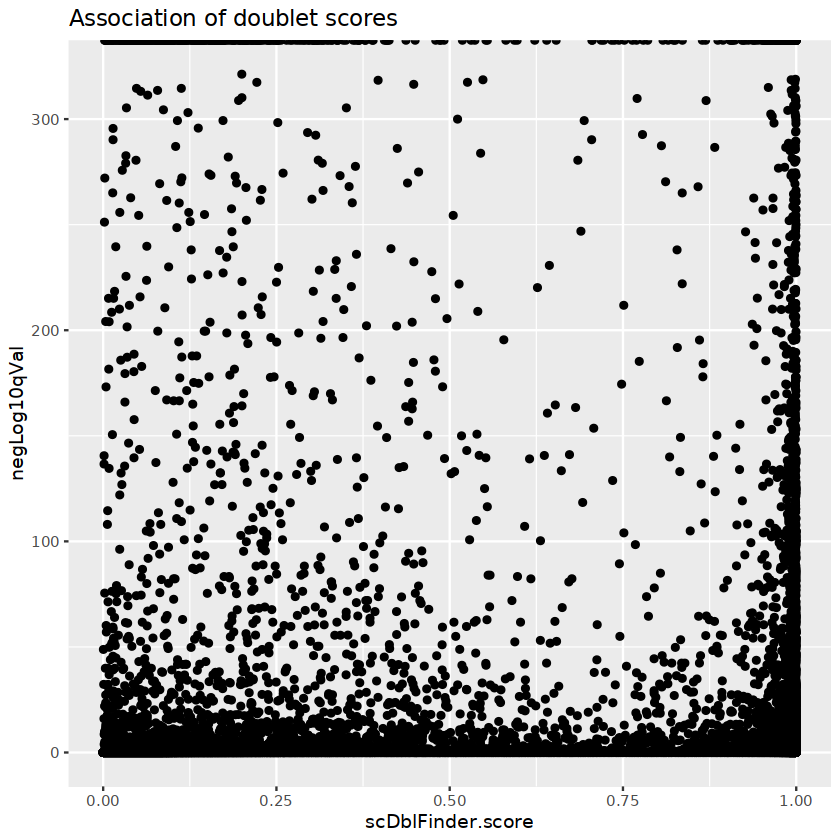

In [13]:
# Compute the negative logarithm of q.value
multiome_merged$negLog10qVal <- -log10(multiome_merged$q.value)

# Create the scatter plot
ggplot(multiome_merged@meta.data, aes(x = scDblFinder.score, y = negLog10qVal)) +
  geom_point() +
  labs(title = "Association of doublet scores")